# Test d'Encodeurs pour Feedbacks Techniques

Ce notebook explore différents encodeurs de langage naturel spécialisés dans le vocabulaire technique informatique.

**Objectifs:**
- Tester plusieurs modèles d'embedding sur vos feedbacks générés
- Comparer leur capacité à capturer le sens technique
- Analyser la similarité sémantique entre feedbacks
- Visualiser les embeddings dans l'espace latent

## 1. Setup & Imports

In [4]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Dict
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Transformers
from transformers import AutoModel, AutoTokenizer
from sentence_transformers import SentenceTransformer

# Dimensionality reduction
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# HuggingFace datasets
from datasets import load_dataset

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'}")

PyTorch version: 2.9.1
Device: mps


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


## 2. Chargement des Données

In [6]:
# Charger votre dataset RAFT
dataset = load_dataset("matis35/RAFT")

print(f"Available splits: {list(dataset.keys())}")
for split_name, split_data in dataset.items():
    print(f"  {split_name}: {len(split_data)} samples")

Available splits: ['train', 'validation', 'test']
  train: 9445 samples
  validation: 1180 samples
  test: 1181 samples


In [7]:
# Combiner tous les splits en un DataFrame
all_dfs = []
for split_name, split_data in dataset.items():
    df = split_data.to_pandas()
    all_dfs.append(df)

df = pd.concat(all_dfs, ignore_index=True)
print(f"Total samples: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst feedback examples:")
for i in range(min(3, len(df))):
    print(f"\n{i+1}. {df.iloc[i]['feedback'][:200]}...")

Total samples: 11806

Columns: ['code', 'feedback']

First feedback examples:

1. When comparing strings, the function should first check for differences in characters before comparing lengths.

The student can identify his bug by looking at the order of operations in his function....

2. The function does not handle the case where either string ends before `n` characters are compared. This could lead to comparing undefined values....

3. When incrementing to find a value meeting a condition, ensure the starting point itself is checked to avoid skipping it if it already meets the condition....


## 3. Définition des Modèles à Tester

Nous allons tester plusieurs catégories de modèles:

### Modèles Sentence Transformers (optimisés pour la similarité sémantique)
- **all-MiniLM-L6-v2**: Léger, rapide, bon pour texte général
- **all-mpnet-base-v2**: Plus performant, meilleur pour nuances sémantiques

### Modèles spécialisés Code
- **codebert-base**: Pré-entraîné sur code + NL
- **graphcodebert-base**: Comprend la structure du code

### Modèles techniques/scientifiques
- **allenai/scibert_scivocab_uncased**: Vocabulaire scientifique
- **microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract**: Texte technique structuré

In [8]:
# Configuration des modèles à tester
MODELS_CONFIG = {
    # Sentence Transformers (usage direct)
    "all-MiniLM-L6-v2": {
        "type": "sentence-transformer",
        "name": "sentence-transformers/all-MiniLM-L6-v2",
        "description": "Léger et rapide, bon pour texte général"
    },
    "all-mpnet-base-v2": {
        "type": "sentence-transformer",
        "name": "sentence-transformers/all-mpnet-base-v2",
        "description": "Plus performant pour nuances sémantiques"
    },
    
    # Modèles Code (nécessitent mean pooling)
    "codebert-base": {
        "type": "transformer",
        "name": "microsoft/codebert-base",
        "description": "Pré-entraîné sur code + langage naturel"
    },
    "graphcodebert-base": {
        "type": "transformer",
        "name": "microsoft/graphcodebert-base",
        "description": "Comprend structure et dataflow du code"
    },
    
    # Modèles techniques/scientifiques
    "scibert": {
        "type": "transformer",
        "name": "allenai/scibert_scivocab_uncased",
        "description": "Vocabulaire scientifique technique"
    },
}

print("Modèles à tester:")
for key, config in MODELS_CONFIG.items():
    print(f"  • {key}: {config['description']}")

Modèles à tester:
  • all-MiniLM-L6-v2: Léger et rapide, bon pour texte général
  • all-mpnet-base-v2: Plus performant pour nuances sémantiques
  • codebert-base: Pré-entraîné sur code + langage naturel
  • graphcodebert-base: Comprend structure et dataflow du code
  • scibert: Vocabulaire scientifique technique


## 4. Fonctions d'Encodage

In [9]:
def mean_pooling(token_embeddings, attention_mask):
    """Mean pooling avec masque d'attention."""
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
    sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
    return sum_embeddings / sum_mask


class TextEncoder:
    """Wrapper unifié pour différents types de modèles."""
    
    def __init__(self, model_name: str, model_type: str, device: torch.device):
        self.model_name = model_name
        self.model_type = model_type
        self.device = device
        
        if model_type == "sentence-transformer":
            self.model = SentenceTransformer(model_name, device=str(device))
            self.tokenizer = None
        else:
            self.tokenizer = AutoTokenizer.from_pretrained(model_name)
            self.model = AutoModel.from_pretrained(model_name).to(device)
            self.model.eval()
    
    @torch.no_grad()
    def encode(self, texts: List[str], batch_size: int = 32, normalize: bool = True) -> np.ndarray:
        """Encode une liste de textes en embeddings."""
        if self.model_type == "sentence-transformer":
            embeddings = self.model.encode(
                texts,
                batch_size=batch_size,
                show_progress_bar=True,
                normalize_embeddings=normalize
            )
            return embeddings
        
        else:
            all_embeddings = []
            
            for i in tqdm(range(0, len(texts), batch_size), desc="Encoding"):
                batch_texts = texts[i:i+batch_size]
                
                encoded = self.tokenizer(
                    batch_texts,
                    padding=True,
                    truncation=True,
                    max_length=512,
                    return_tensors='pt'
                )
                
                encoded = {k: v.to(self.device) for k, v in encoded.items()}
                
                outputs = self.model(**encoded)
                embeddings = mean_pooling(outputs.last_hidden_state, encoded['attention_mask'])
                
                if normalize:
                    embeddings = F.normalize(embeddings, p=2, dim=1)
                
                all_embeddings.append(embeddings.cpu().numpy())
            
            return np.vstack(all_embeddings)


print("✓ Fonctions d'encodage définies")

✓ Fonctions d'encodage définies


## 5. Échantillonnage des Feedbacks pour Tests

In [10]:
# Sélectionner un échantillon pour les tests
SAMPLE_SIZE = 500  # Ajustez selon vos besoins

if len(df) > SAMPLE_SIZE:
    df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
else:
    df_sample = df.copy()

feedbacks = df_sample['feedback'].tolist()

print(f"Échantillon sélectionné: {len(feedbacks)} feedbacks")
print(f"\nExemples de feedbacks:")
for i in range(3):
    print(f"\n{i+1}. {feedbacks[i][:150]}...")

Échantillon sélectionné: 500 feedbacks

Exemples de feedbacks:

1. When copying a specified number of characters from one string to another, ensure that the destination string is properly null-terminated, especially w...

2. Your function does not handle the case where the source string is shorter than the specified number of characters. This can lead to copying invalid me...

3. The recursive function does not handle all base cases correctly, leading to potential infinite recursion or incorrect results for certain inputs. Chec...


## 6. Encodage avec Tous les Modèles

In [11]:
# Dictionnaire pour stocker les embeddings de chaque modèle
embeddings_dict = {}

for model_key, config in MODELS_CONFIG.items():
    print(f"\n{'='*80}")
    print(f"Encodage avec: {model_key}")
    print(f"Description: {config['description']}")
    print(f"{'='*80}")
    
    try:
        encoder = TextEncoder(
            model_name=config['name'],
            model_type=config['type'],
            device=device
        )
        
        embeddings = encoder.encode(feedbacks, batch_size=32, normalize=True)
        embeddings_dict[model_key] = embeddings
        
        print(f"✓ Embeddings shape: {embeddings.shape}")
        print(f"✓ Embedding dimension: {embeddings.shape[1]}")
        
        # Libérer la mémoire GPU
        if hasattr(encoder, 'model'):
            del encoder.model
        if hasattr(encoder, 'tokenizer'):
            del encoder.tokenizer
        del encoder
        
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        elif torch.backends.mps.is_available():
            torch.mps.empty_cache()
        
    except Exception as e:
        print(f"✗ Erreur lors de l'encodage: {e}")
        embeddings_dict[model_key] = None

print(f"\n{'='*80}")
print(f"Encodage terminé pour {len([k for k, v in embeddings_dict.items() if v is not None])}/{len(MODELS_CONFIG)} modèles")
print(f"{'='*80}")


Encodage avec: all-MiniLM-L6-v2
Description: Léger et rapide, bon pour texte général


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

✓ Embeddings shape: (500, 384)
✓ Embedding dimension: 384

Encodage avec: all-mpnet-base-v2
Description: Plus performant pour nuances sémantiques


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

✓ Embeddings shape: (500, 768)
✓ Embedding dimension: 768

Encodage avec: codebert-base
Description: Pré-entraîné sur code + langage naturel


...

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Encoding:   0%|          | 0/16 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

✓ Embeddings shape: (500, 768)
✓ Embedding dimension: 768

Encodage terminé pour 5/5 modèles


## 7. Analyse de la Qualité des Embeddings

### 7.1 Distribution de Similarité

In [12]:
def analyze_embedding_quality(embeddings: np.ndarray, model_name: str):
    """Analyse la qualité et les propriétés des embeddings."""
    
    # Similarité cosine pairwise
    similarities = cosine_similarity(embeddings)
    
    # Masquer la diagonale (similarité avec soi-même)
    mask = np.eye(similarities.shape[0], dtype=bool)
    similarities_no_diag = similarities[~mask]
    
    stats = {
        'mean_similarity': similarities_no_diag.mean(),
        'std_similarity': similarities_no_diag.std(),
        'min_similarity': similarities_no_diag.min(),
        'max_similarity': similarities_no_diag.max(),
        'median_similarity': np.median(similarities_no_diag),
        'embedding_norm_mean': np.linalg.norm(embeddings, axis=1).mean(),
        'embedding_norm_std': np.linalg.norm(embeddings, axis=1).std(),
    }
    
    return similarities, stats


# Analyser chaque modèle
similarity_matrices = {}
quality_stats = {}

for model_key, embeddings in embeddings_dict.items():
    if embeddings is not None:
        print(f"\nAnalyse: {model_key}")
        similarities, stats = analyze_embedding_quality(embeddings, model_key)
        similarity_matrices[model_key] = similarities
        quality_stats[model_key] = stats
        
        print(f"  Mean similarity: {stats['mean_similarity']:.3f} ± {stats['std_similarity']:.3f}")
        print(f"  Range: [{stats['min_similarity']:.3f}, {stats['max_similarity']:.3f}]")
        print(f"  Embedding norm: {stats['embedding_norm_mean']:.3f} ± {stats['embedding_norm_std']:.3f}")


Analyse: all-MiniLM-L6-v2
  Mean similarity: 0.308 ± 0.156
  Range: [-0.116, 1.000]
  Embedding norm: 1.000 ± 0.000

Analyse: all-mpnet-base-v2
  Mean similarity: 0.316 ± 0.160
  Range: [-0.100, 1.000]
  Embedding norm: 1.000 ± 0.000

Analyse: codebert-base
  Mean similarity: 0.980 ± 0.007
  Range: [0.906, 1.000]
  Embedding norm: 1.000 ± 0.000

Analyse: graphcodebert-base
  Mean similarity: 0.840 ± 0.045
  Range: [0.595, 1.000]
  Embedding norm: 1.000 ± 0.000

Analyse: scibert
  Mean similarity: 0.860 ± 0.034
  Range: [0.680, 1.000]
  Embedding norm: 1.000 ± 0.000


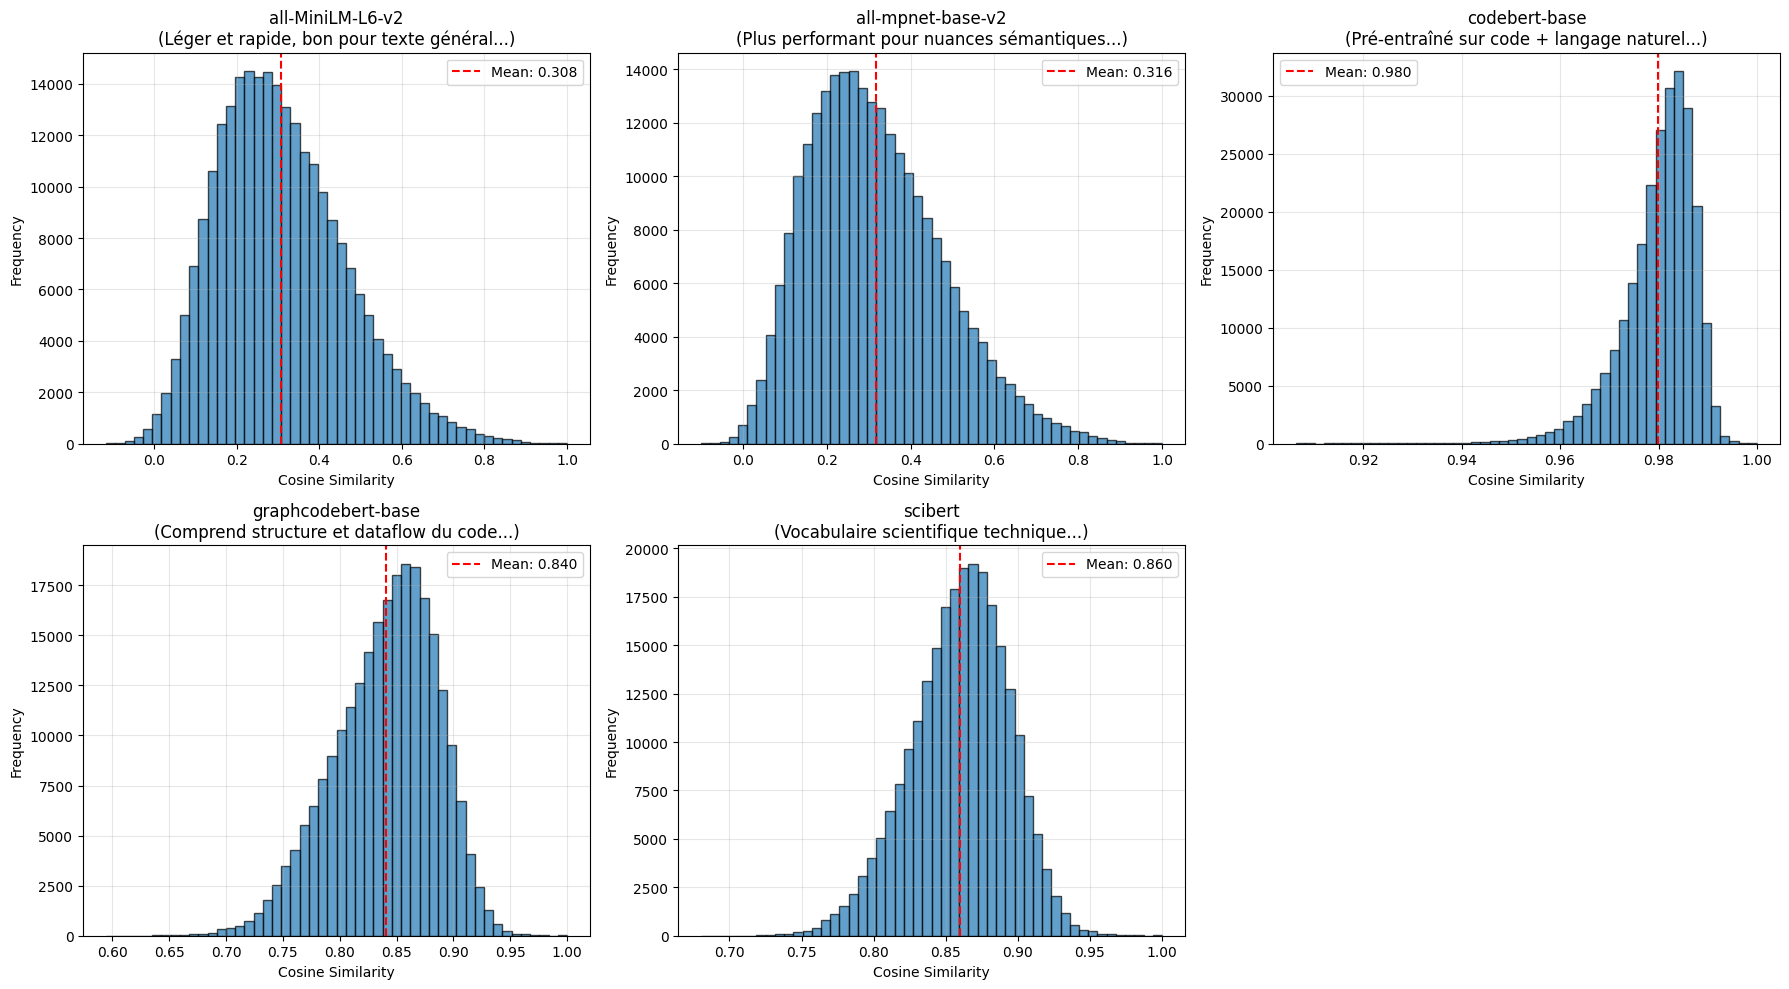

✓ Distribution de similarité visualisée


In [13]:
# Visualiser les distributions de similarité
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (model_key, similarities) in enumerate(similarity_matrices.items()):
    if idx >= len(axes):
        break
    
    mask = np.eye(similarities.shape[0], dtype=bool)
    similarities_no_diag = similarities[~mask]
    
    ax = axes[idx]
    ax.hist(similarities_no_diag, bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(similarities_no_diag.mean(), color='red', linestyle='--', 
               label=f'Mean: {similarities_no_diag.mean():.3f}')
    ax.set_xlabel('Cosine Similarity')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{model_key}\n({MODELS_CONFIG[model_key]["description"][:40]}...)')
    ax.legend()
    ax.grid(alpha=0.3)

# Cacher les axes non utilisés
for idx in range(len(similarity_matrices), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('similarity_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Distribution de similarité visualisée")

### 7.2 Comparaison des Statistiques


COMPARAISON DES STATISTIQUES D'EMBEDDING
                    mean_similarity  std_similarity  min_similarity  max_similarity  median_similarity  embedding_norm_mean  embedding_norm_std
all-MiniLM-L6-v2             0.3077          0.1555         -0.1164             1.0             0.2902                  1.0                 0.0
all-mpnet-base-v2            0.3164          0.1598         -0.0999             1.0             0.2970                  1.0                 0.0
codebert-base                0.9800          0.0074          0.9064             1.0             0.9814                  1.0                 0.0
graphcodebert-base           0.8404          0.0452          0.5945             1.0             0.8457                  1.0                 0.0
scibert                      0.8597          0.0339          0.6804             1.0             0.8621                  1.0                 0.0


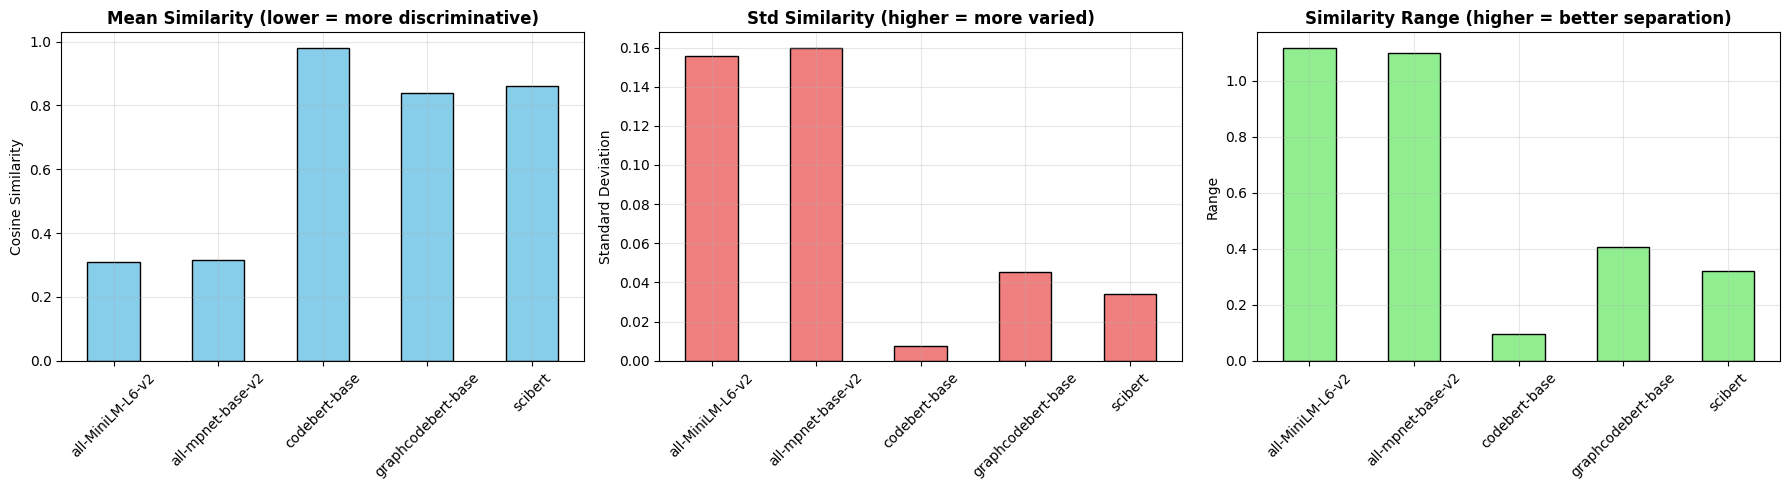


✓ Statistiques comparées


In [14]:
# Créer un DataFrame de comparaison
stats_df = pd.DataFrame(quality_stats).T
stats_df = stats_df.round(4)

print("\n" + "="*100)
print("COMPARAISON DES STATISTIQUES D'EMBEDDING")
print("="*100)
print(stats_df.to_string())
print("="*100)

# Visualisation comparative
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mean similarity
stats_df['mean_similarity'].plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Mean Similarity (lower = more discriminative)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cosine Similarity')
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Std similarity
stats_df['std_similarity'].plot(kind='bar', ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Std Similarity (higher = more varied)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Standard Deviation')
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Range (max - min)
similarity_range = stats_df['max_similarity'] - stats_df['min_similarity']
similarity_range.plot(kind='bar', ax=axes[2], color='lightgreen', edgecolor='black')
axes[2].set_title('Similarity Range (higher = better separation)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Range')
axes[2].grid(alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('embedding_statistics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Statistiques comparées")

## 8. Visualisation t-SNE des Embeddings

In [15]:
# Réduire la dimensionnalité avec t-SNE pour visualisation
tsne_results = {}

print("Réduction de dimensionnalité avec t-SNE...\n")

for model_key, embeddings in embeddings_dict.items():
    if embeddings is not None:
        print(f"Processing: {model_key}")
        
        # Appliquer PCA d'abord pour réduire le temps de calcul
        pca = PCA(n_components=50)
        embeddings_pca = pca.fit_transform(embeddings)
        
        # Puis t-SNE
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        embeddings_2d = tsne.fit_transform(embeddings_pca)
        
        tsne_results[model_key] = embeddings_2d
        print(f"  ✓ Shape: {embeddings_2d.shape}")

print("\n✓ Réduction terminée")

Réduction de dimensionnalité avec t-SNE...

Processing: all-MiniLM-L6-v2


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  ✓ Shape: (500, 2)
Processing: all-mpnet-base-v2
  ✓ Shape: (500, 2)
Processing: codebert-base
  ✓ Shape: (500, 2)
Processing: graphcodebert-base
  ✓ Shape: (500, 2)
Processing: scibert
  ✓ Shape: (500, 2)

✓ Réduction terminée


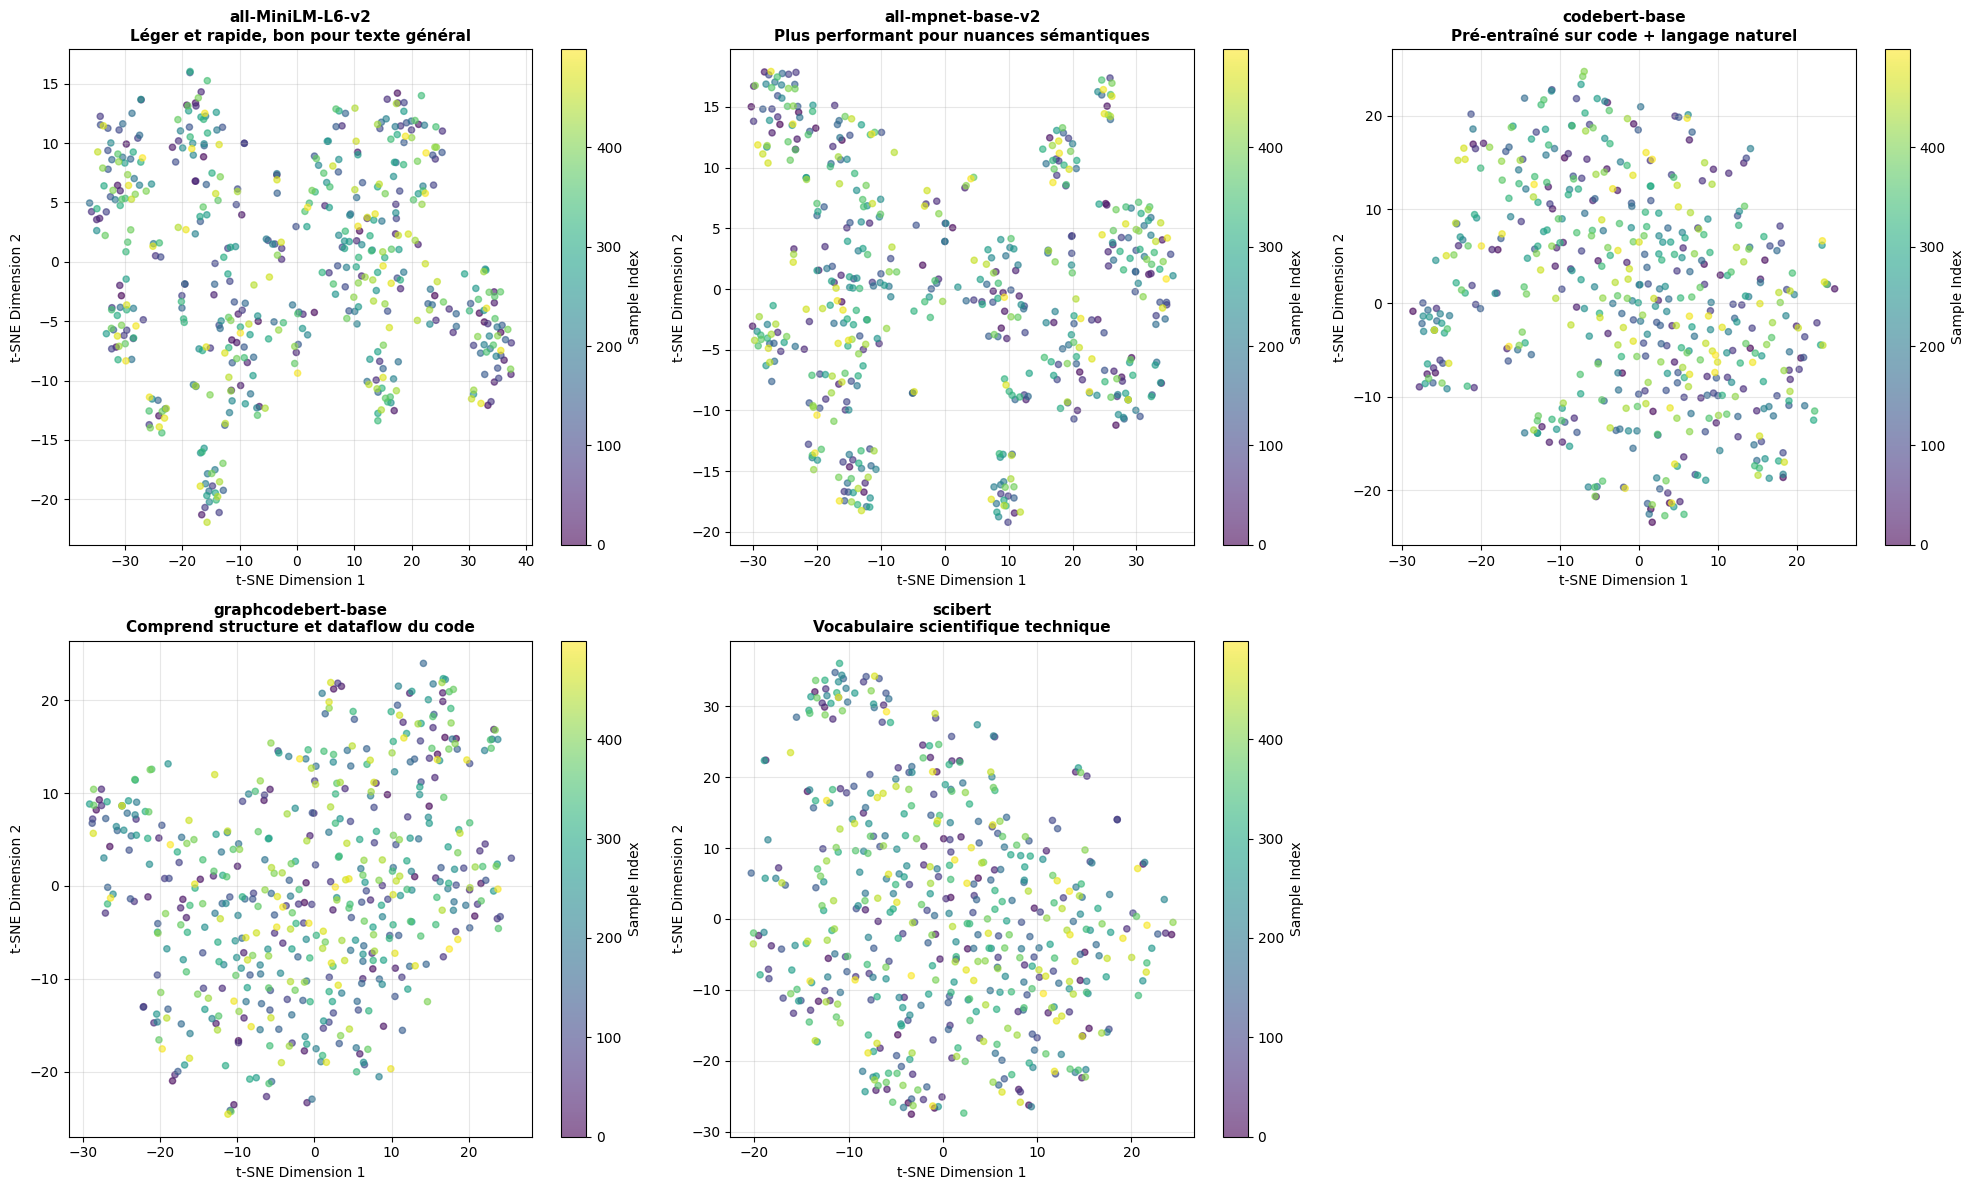

✓ Visualisation t-SNE générée


In [16]:
# Visualiser les embeddings t-SNE
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, (model_key, embeddings_2d) in enumerate(tsne_results.items()):
    if idx >= len(axes):
        break
    
    ax = axes[idx]
    scatter = ax.scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        c=range(len(embeddings_2d)),
        cmap='viridis',
        alpha=0.6,
        s=20
    )
    
    ax.set_title(f'{model_key}\n{MODELS_CONFIG[model_key]["description"]}', 
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
    ax.grid(alpha=0.3)
    
    # Ajouter colorbar
    plt.colorbar(scatter, ax=ax, label='Sample Index')

# Cacher axes non utilisés
for idx in range(len(tsne_results), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualisation t-SNE générée")

## 9. Test de Requête Sémantique

Testons la capacité des modèles à retrouver des feedbacks pertinents pour une requête technique.

In [17]:
# Définir des requêtes de test techniques
TEST_QUERIES = [
    "memory leak and performance issues",
    "null pointer exception handling",
    "inefficient algorithm complexity",
    "security vulnerability in authentication",
    "missing error handling and edge cases"
]

def find_most_similar(query: str, embeddings: np.ndarray, texts: List[str], 
                     encoder: TextEncoder, top_k: int = 5):
    """Trouve les textes les plus similaires à une requête."""
    query_embedding = encoder.encode([query], normalize=True)
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    top_indices = np.argsort(similarities)[-top_k:][::-1]
    
    results = []
    for idx in top_indices:
        results.append({
            'index': idx,
            'similarity': similarities[idx],
            'text': texts[idx]
        })
    
    return results

print("Test queries:")
for i, query in enumerate(TEST_QUERIES, 1):
    print(f"  {i}. {query}")

Test queries:
  1. memory leak and performance issues
  2. null pointer exception handling
  3. inefficient algorithm complexity
  4. security vulnerability in authentication
  5. missing error handling and edge cases


In [18]:
# Tester chaque modèle sur la première requête
test_query = TEST_QUERIES[0]
print(f"{'='*100}")
print(f"QUERY: '{test_query}'")
print(f"{'='*100}\n")

for model_key, config in MODELS_CONFIG.items():
    if model_key not in embeddings_dict or embeddings_dict[model_key] is None:
        continue
    
    print(f"\n{'-'*100}")
    print(f"Model: {model_key}")
    print(f"{'-'*100}")
    
    # Recharger l'encoder pour cette requête
    encoder = TextEncoder(
        model_name=config['name'],
        model_type=config['type'],
        device=device
    )
    
    results = find_most_similar(
        query=test_query,
        embeddings=embeddings_dict[model_key],
        texts=feedbacks,
        encoder=encoder,
        top_k=3
    )
    
    for i, result in enumerate(results, 1):
        print(f"\n{i}. Similarity: {result['similarity']:.4f}")
        print(f"   Text: {result['text'][:200]}...")
    
    # Libérer mémoire
    del encoder
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()

print(f"\n{'='*100}")

QUERY: 'memory leak and performance issues'


----------------------------------------------------------------------------------------------------
Model: all-MiniLM-L6-v2
----------------------------------------------------------------------------------------------------


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


1. Similarity: 0.4502
   Text: Consider the case when the second parameter is very large. What will happen to the stack memory? This issue is due to the lack of a base case for large values....

2. Similarity: 0.4371
   Text: The loop condition will access an invalid memory location. Check the range of values being iterated over....

3. Similarity: 0.3727
   Text: Check the memory allocation handling. The code may lead to memory leaks because the original pointer is overwritten without freeing the duplicated string. Additionally, consider the edge case where th...

----------------------------------------------------------------------------------------------------
Model: all-mpnet-base-v2
----------------------------------------------------------------------------------------------------


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


1. Similarity: 0.4052
   Text: When accessing elements at the boundaries of an array, ensure that the indices are within valid ranges to avoid accessing out-of-bounds memory. Check the conditions that depend on previous elements ca...

2. Similarity: 0.3598
   Text: Consider the case when the second parameter is very large. What will happen to the stack memory? This issue is due to the lack of a base case for large values....

3. Similarity: 0.3503
   Text: When accessing an element at index i, ensure that i-1 is a valid index to avoid accessing memory out of bounds....

----------------------------------------------------------------------------------------------------
Model: codebert-base
----------------------------------------------------------------------------------------------------


...

Some weights of RobertaModel were not initialized from the model checkpoint at microsoft/graphcodebert-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Encoding:   0%|          | 0/1 [00:00<?, ?it/s]


1. Similarity: 0.7656
   Text: The recursive function may encounter stack overflow for certain inputs. Consider edge cases and the typical limitations of recursion....

2. Similarity: 0.7644
   Text: Your recursive function may produce incorrect results due to integer overflow....

3. Similarity: 0.7496
   Text: The function may not handle overlapping source and destination buffers correctly, leading to potential data corruption. Always consider edge cases where memory regions overlap when copying data....

----------------------------------------------------------------------------------------------------
Model: scibert
----------------------------------------------------------------------------------------------------


Encoding:   0%|          | 0/1 [00:00<?, ?it/s]


1. Similarity: 0.7459
   Text: Consider checking for potential array index out-of-bounds access, as it could lead to undefined behavior....

2. Similarity: 0.7452
   Text: The function may not handle overlapping source and destination buffers correctly, leading to potential data corruption. Always consider edge cases where memory regions overlap when copying data....

3. Similarity: 0.7428
   Text: Consider the order of operations and the impact of conditional checks on the computation....



## 10. Analyse de Vocabulaire Technique

Analysons quels termes techniques sont les plus présents dans vos feedbacks.

In [19]:
from collections import Counter
import re

# Termes techniques à chercher
TECHNICAL_TERMS = [
    # Concepts de base
    'null', 'pointer', 'exception', 'error', 'bug', 'memory', 'leak',
    'performance', 'optimization', 'complexity', 'algorithm', 'function',
    'variable', 'parameter', 'argument', 'return', 'type', 'class',
    
    # Sécurité
    'security', 'vulnerability', 'authentication', 'authorization', 'injection',
    'sanitize', 'validate', 'escape', 'encryption', 'credential',
    
    # Architecture
    'api', 'interface', 'abstract', 'inherit', 'polymorphism', 'encapsulation',
    'refactor', 'design pattern', 'coupling', 'cohesion',
    
    # Testing/Quality
    'test', 'unittest', 'assertion', 'coverage', 'edge case', 'corner case',
    'regression', 'deprecated', 'documentation', 'comment',
    
    # Concurrence
    'thread', 'race condition', 'deadlock', 'mutex', 'synchronization',
    'async', 'parallel', 'concurrent',
]

def extract_technical_terms(texts: List[str], terms: List[str]) -> Dict[str, int]:
    """Compte les occurrences de termes techniques."""
    combined_text = ' '.join(texts).lower()
    
    term_counts = {}
    for term in terms:
        # Utiliser \b pour word boundaries
        pattern = r'\b' + re.escape(term.lower()) + r'\b'
        count = len(re.findall(pattern, combined_text))
        if count > 0:
            term_counts[term] = count
    
    return term_counts

# Analyser les feedbacks
term_counts = extract_technical_terms(feedbacks, TECHNICAL_TERMS)
term_counts_sorted = dict(sorted(term_counts.items(), key=lambda x: x[1], reverse=True))

print(f"\n{'='*100}")
print("TOP TECHNICAL TERMS IN FEEDBACKS")
print(f"{'='*100}\n")

for i, (term, count) in enumerate(list(term_counts_sorted.items())[:20], 1):
    print(f"{i:2d}. {term:25s} → {count:4d} occurrences")

print(f"\n{'='*100}")


TOP TECHNICAL TERMS IN FEEDBACKS

 1. function                  →  188 occurrences
 2. null                      →   71 occurrences
 3. return                    →   63 occurrences
 4. error                     →   49 occurrences
 5. variable                  →   47 occurrences
 6. edge case                 →   35 occurrences
 7. type                      →   24 occurrences
 8. memory                    →   20 occurrences
 9. pointer                   →   13 occurrences
10. parameter                 →   12 occurrences
11. argument                  →    4 occurrences
12. bug                       →    3 occurrences
13. performance               →    1 occurrences
14. security                  →    1 occurrences
15. vulnerability             →    1 occurrences
16. validate                  →    1 occurrences



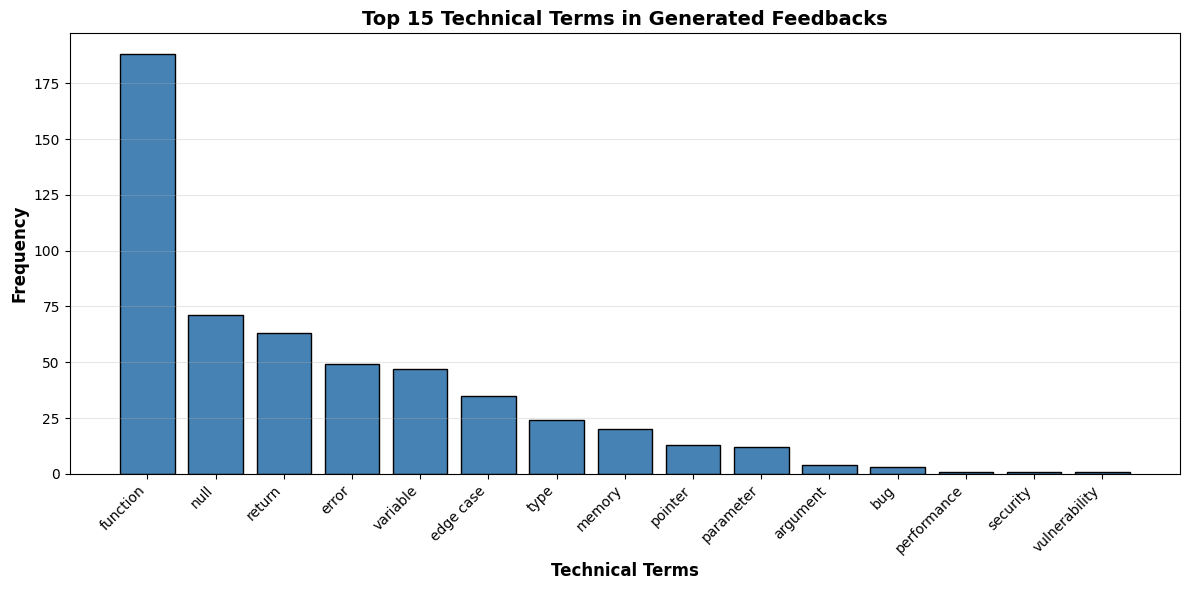

✓ Visualisation des termes techniques générée


In [20]:
# Visualiser les termes les plus fréquents
top_terms = dict(list(term_counts_sorted.items())[:15])

plt.figure(figsize=(12, 6))
plt.bar(top_terms.keys(), top_terms.values(), color='steelblue', edgecolor='black')
plt.xlabel('Technical Terms', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Top 15 Technical Terms in Generated Feedbacks', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('technical_terms_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualisation des termes techniques générée")

## 11. Recommandations Finales

Analysons les résultats pour recommander le meilleur modèle.

In [21]:
print(f"\n{'='*100}")
print("RECOMMANDATIONS DE MODÈLES")
print(f"{'='*100}\n")

# Critères de qualité
print("Critères d'évaluation:")
print("  1. Mean similarity (plus bas = meilleure discrimination)")
print("  2. Std similarity (plus haut = plus de variété dans les représentations)")
print("  3. Similarity range (plus grand = meilleure séparation positif/négatif)")
print()

# Calculer un score composite
scores = {}
for model_key in quality_stats.keys():
    stats = quality_stats[model_key]
    
    # Normaliser les métriques (lower mean sim = better, higher std = better, higher range = better)
    score = (
        (1 - stats['mean_similarity']) * 0.4 +  # Lower mean similarity is better
        stats['std_similarity'] * 0.3 +          # Higher std is better
        (stats['max_similarity'] - stats['min_similarity']) * 0.3  # Higher range is better
    )
    
    scores[model_key] = score

# Trier par score
ranked_models = sorted(scores.items(), key=lambda x: x[1], reverse=True)

print(f"{'='*100}")
print("RANKING (Score composite basé sur discrimination et variété)")
print(f"{'='*100}\n")

for i, (model_key, score) in enumerate(ranked_models, 1):
    stats = quality_stats[model_key]
    print(f"{i}. {model_key} (Score: {score:.4f})")
    print(f"   Description: {MODELS_CONFIG[model_key]['description']}")
    print(f"   Mean sim: {stats['mean_similarity']:.4f} | Std: {stats['std_similarity']:.4f} | Range: {stats['max_similarity']-stats['min_similarity']:.4f}")
    print()

print(f"{'='*100}")
print("RECOMMANDATION FINALE")
print(f"{'='*100}\n")

best_model = ranked_models[0][0]
print(f"✨ Meilleur modèle pour vos feedbacks techniques: {best_model}")
print(f"   {MODELS_CONFIG[best_model]['description']}")
print(f"\n   Ce modèle offre le meilleur compromis entre:")
print(f"   • Capacité de discrimination entre feedbacks différents")
print(f"   • Variété dans les représentations")
print(f"   • Séparation claire entre similarités positives et négatives")
print(f"\n{'='*100}")


RECOMMANDATIONS DE MODÈLES

Critères d'évaluation:
  1. Mean similarity (plus bas = meilleure discrimination)
  2. Std similarity (plus haut = plus de variété dans les représentations)
  3. Similarity range (plus grand = meilleure séparation positif/négatif)

RANKING (Score composite basé sur discrimination et variété)

1. all-MiniLM-L6-v2 (Score: 0.6585)
   Description: Léger et rapide, bon pour texte général
   Mean sim: 0.3077 | Std: 0.1555 | Range: 1.1164

2. all-mpnet-base-v2 (Score: 0.6514)
   Description: Plus performant pour nuances sémantiques
   Mean sim: 0.3164 | Std: 0.1598 | Range: 1.0999

3. graphcodebert-base (Score: 0.1990)
   Description: Comprend structure et dataflow du code
   Mean sim: 0.8404 | Std: 0.0452 | Range: 0.4055

4. scibert (Score: 0.1622)
   Description: Vocabulaire scientifique technique
   Mean sim: 0.8597 | Std: 0.0339 | Range: 0.3196

5. codebert-base (Score: 0.0383)
   Description: Pré-entraîné sur code + langage naturel
   Mean sim: 0.9800 | Std: 

## 12. Sauvegarde des Résultats

In [22]:
import pickle
from datetime import datetime

# Créer un dossier pour les résultats
results_dir = Path('./encoder_test_results')
results_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Sauvegarder les embeddings
embeddings_path = results_dir / f'embeddings_{timestamp}.pkl'
with open(embeddings_path, 'wb') as f:
    pickle.dump(embeddings_dict, f)
print(f"✓ Embeddings sauvegardés: {embeddings_path}")

# Sauvegarder les statistiques
stats_path = results_dir / f'quality_stats_{timestamp}.csv'
stats_df.to_csv(stats_path)
print(f"✓ Statistiques sauvegardées: {stats_path}")

# Sauvegarder le ranking
ranking_df = pd.DataFrame(ranked_models, columns=['model', 'score'])
ranking_path = results_dir / f'model_ranking_{timestamp}.csv'
ranking_df.to_csv(ranking_path, index=False)
print(f"✓ Ranking sauvegardé: {ranking_path}")

print(f"\n✓ Tous les résultats sauvegardés dans: {results_dir}")

✓ Embeddings sauvegardés: encoder_test_results/embeddings_20251204_172308.pkl
✓ Statistiques sauvegardées: encoder_test_results/quality_stats_20251204_172308.csv
✓ Ranking sauvegardé: encoder_test_results/model_ranking_20251204_172308.csv

✓ Tous les résultats sauvegardés dans: encoder_test_results


## 13. Test Interactif (Optionnel)

Testez vos propres requêtes ici!

In [23]:
# Fonction interactive pour tester vos propres requêtes
def interactive_search(model_key: str, custom_query: str = None, top_k: int = 5):
    """
    Recherche interactive avec un modèle spécifique.
    
    Args:
        model_key: Clé du modèle à utiliser (ex: 'all-mpnet-base-v2')
        custom_query: Votre requête personnalisée
        top_k: Nombre de résultats à retourner
    """
    if model_key not in embeddings_dict or embeddings_dict[model_key] is None:
        print(f"❌ Modèle '{model_key}' non disponible")
        return
    
    if custom_query is None:
        custom_query = input("Entrez votre requête: ")
    
    config = MODELS_CONFIG[model_key]
    encoder = TextEncoder(
        model_name=config['name'],
        model_type=config['type'],
        device=device
    )
    
    results = find_most_similar(
        query=custom_query,
        embeddings=embeddings_dict[model_key],
        texts=feedbacks,
        encoder=encoder,
        top_k=top_k
    )
    
    print(f"\n{'='*100}")
    print(f"Query: '{custom_query}'")
    print(f"Model: {model_key}")
    print(f"{'='*100}\n")
    
    for i, result in enumerate(results, 1):
        print(f"{i}. Similarity: {result['similarity']:.4f}")
        print(f"   {result['text']}")
        print()
    
    del encoder
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()

# Exemple d'utilisation:
# interactive_search('all-mpnet-base-v2', 'code with memory management issues', top_k=3)

In [24]:
# TESTEZ ICI avec votre propre requête!
# Décommentez et modifiez la ligne ci-dessous:

# interactive_search('all-mpnet-base-v2', 'YOUR QUERY HERE', top_k=5)